# CSE 150A: HMM for Developer Seniority Prediction

**Team:** Iha Gadiya, Ioanna Gkerdouki, Lianna Lim, Ved Panse, William Diego

**Goal:** Model how developer seniority (a latent variable) influences observable survey responses using a Hidden Markov Model.

## PEAS Analysis

- **Performance measure:** Log-likelihood of observation sequences, accuracy of decoded hidden states compared to experience-based ground truth labels.
- **Environment:** Professional developers from the United States who work at companies with 1,000 to 4,999 employees.
- **Actuators:** The agent outputs a probability distribution over seniority levels (junior, mid-level, senior) and decodes the most likely hidden state sequence.
- **Sensors:** `AISelect`, `YearsCode`, `YearsCodePro`, `CodingActivities`, `DevType`, `OrgSize`, and `ConvertedCompYearly`.

The problem we are solving is: given a sequence of observable developer attributes, can we infer their underlying seniority level over time? The HMM allows us to model seniority as a hidden state that transitions (career progression) and emits observable features (survey responses).

## Dataset Overview

We used the Stack Overflow Developer Survey 2023 dataset from Kaggle. Our cleaned dataset is in `cleaned_data/cleaned_stackoverflow_bn_data.csv`.

**Filtering criteria:**
- Country: United States of America
- OrgSize: 1,000 to 4,999 employees
- DevType: Contains "Developer"
- No missing values in selected columns

**Final dataset:** 1,106 rows

### Variables Used

| Variable | Values | Description |
| --- | --- | --- |
| `DevType` | full_stack, back_end, front_end, mobile, applications, embedded, qa, advocate, game_graphics, experience | Developer role |
| `AISelect` | yes, no, plan_to | AI tool usage |
| `YearsCode` | low, medium, high | Total coding experience |
| `YearsCodePro` | low, medium, high | Professional coding experience |
| `CodingActivities` | codes_as_hobby, no_code_as_hobby | Codes outside work |
| `ConvertedCompYearly` | low, medium, high, very_high | Yearly compensation quartile |

## Latent Variable Identification (Ioanna)

The latent variable in our dataset is **Developer Seniority**, which represents a developer's career stage or experience level, such as junior, mid-level, or senior. This variable is latent because the Stack Overflow survey does not directly ask respondents to classify themselves into explicit seniority tiers. Instead, we observe features that are influenced by a developer's underlying seniority level. A developer's seniority affects the types of roles they hold (DevType), their likelihood of adopting AI tools (AISelect), whether they code outside of work (CodingActivities), and their yearly compensation (ConvertedCompYearly). For example, a senior developer is more likely to hold a back-end or full-stack position, earn a higher salary, and have established coding habits compared to a junior developer. In our Bayesian Network, we used ConvertedCompYearly as a proxy for skill, with observed features pointing toward salary as the outcome. However, in the HMM, we reverse this perspective: Developer Seniority becomes the hidden state that generates the observed survey responses. The hidden states (junior, mid-level, senior) transition over time to model career progression, and each state probabilistically emits the observed features. This structure aligns with the HMM framework, where the hidden state causally influences the observations rather than being the end result of them.

## Part 2: Temporal Data Construction (Iha)

This dataset does not contain an explicit timestamp or natural temporal ordering between samples. However, the variables YearsCodePro and YearsCode model career progression and can be used to convert tabular data into a sequential format. 

Developer Seniority represents a developer's career stage or experience level, such as junior, mid-level, or senior. This latent variable is dependent on time and thus can be categorized by years of coding experience using the variables YearsCodePro and YearsCode. 

To impose sequential structure on the tabular dataset, we first sort the samples by YearsCodePro (low, medium, high). This variable serves as the primary temporal ordering because professional coding experience most naturally reflects progression through a software development career. Within each YearsCodePro category, samples are ordered again using YearsCode, representing total coding experience. This acts as a tie breaker between developers with similar professional experience levels.

The observed variables used as HMM emissions are DevType, AISelect, CodingActivities, and ConvertedCompYearly. These variables are discretized prior to HMM training to allow the observations to be represented as finite emission symbols.

### Sequential Dataset Construction

The original survey export is not required to run this notebook. We start from the committed cleaned Bayesian Network data and construct the HMM sequence from it. The ordering is a career-progression proxy: `YearsCodePro` first, then `YearsCode`, both ordered as low, medium, high. This keeps the HMM milestone reproducible from files already in the repository.

In [1]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd()
if not (project_root / "cleaned_data").exists():
    project_root = Path.cwd().parent

bn_path = project_root / "cleaned_data" / "cleaned_stackoverflow_bn_data.csv"
hmm_path = project_root / "cleaned_data" / "cleaned_stackoverflow_hmm_data.csv"

bn_data = pd.read_csv(bn_path)
print(f"Loaded cleaned data: {bn_data.shape}")
display(bn_data.head())

Loaded cleaned data: (1106, 8)


,Country,OrgSize,DevType,AISelect,YearsCode,YearsCodePro,CodingActivities,ConvertedCompYearly
0,USA,medium_size,full_stack,yes,medium,medium,codes_as_hobby,medium
1,USA,medium_size,front_end,yes,high,high,codes_as_hobby,high
2,USA,medium_size,full_stack,no,high,medium,no_code_as_hobby,very_high
3,USA,medium_size,mobile,no,high,high,codes_as_hobby,medium
4,USA,medium_size,back_end,no,high,high,codes_as_hobby,high


In [2]:
order = {"low": 0, "medium": 1, "high": 2}

hmm_data = (
    bn_data.copy()
    .assign(
        YearsCodePro_order=lambda df: df["YearsCodePro"].map(order),
        YearsCode_order=lambda df: df["YearsCode"].map(order),
    )
    .sort_values(["YearsCodePro_order", "YearsCode_order"])
    .drop(columns=["YearsCodePro_order", "YearsCode_order"])
    .reset_index(drop=True)
)

hmm_data.to_csv(hmm_path, index=False)
print(f"Saved HMM sequence data to {hmm_path}")
display(hmm_data.head())

Saved HMM sequence data to /Users/vedpanse/cse-150a/project/cleaned_data/cleaned_stackoverflow_hmm_data.csv


,Country,OrgSize,DevType,AISelect,YearsCode,YearsCodePro,CodingActivities,ConvertedCompYearly
0,USA,medium_size,qa,no,low,low,codes_as_hobby,low
1,USA,medium_size,full_stack,yes,low,low,no_code_as_hobby,low
2,USA,medium_size,front_end,yes,medium,low,codes_as_hobby,medium
3,USA,medium_size,back_end,no,medium,low,no_code_as_hobby,medium
4,USA,medium_size,full_stack,yes,medium,low,codes_as_hobby,low


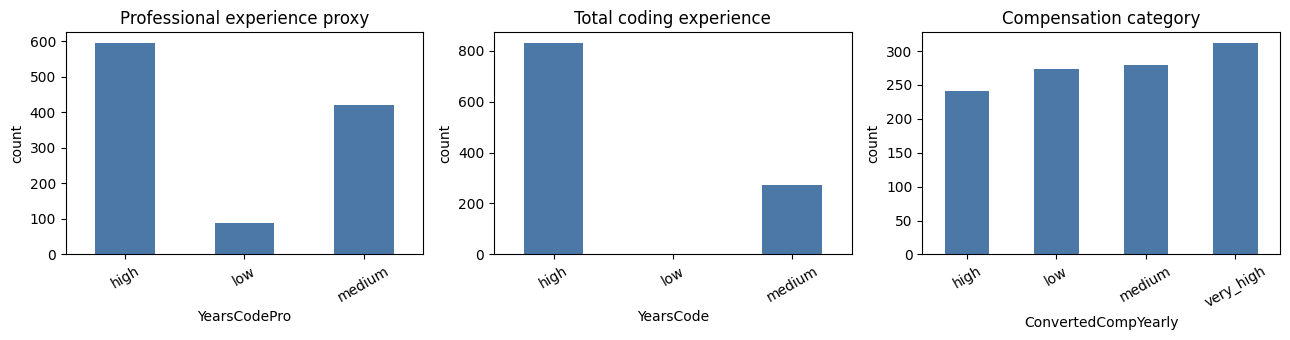

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, column, title in zip(
    axes,
    ["YearsCodePro", "YearsCode", "ConvertedCompYearly"],
    ["Professional experience proxy", "Total coding experience", "Compensation category"],
):
    counts = bn_data[column].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Part 3: HMM Implementation and Parameter Estimation (Lianna)

We implemented a basic discrete Hidden Markov Model in `src/hmm_model.py`. The hidden state is **Developer Seniority** with three latent states: junior, mid-level, and senior. The observed emission symbol at each step is a composite categorical value built from `DevType`, `AISelect`, `YearsCode`, `CodingActivities`, and `ConvertedCompYearly`. We intentionally do not use `YearsCodePro` as an emission because it is our experience-based proxy label for evaluating the decoded hidden states.

The model is trained with the Baum-Welch version of EM. In the E-step, scaled forward-backward inference estimates posterior state responsibilities. In the M-step, those expected counts update the initial state distribution $\pi$, transition matrix $A$, and emission matrix $B$.

In [4]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd() / "src"]:
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

from hmm_model import run_hmm, STATE_NAMES
import pandas as pd

result = run_hmm()

pi_table = pd.Series(result.pi, index=STATE_NAMES, name="probability")
transition_table = pd.DataFrame(result.transition, index=STATE_NAMES, columns=STATE_NAMES)

print("Initial state distribution (pi)")
display(pi_table.round(4))

print("Transition matrix (A)")
display(transition_table.round(4))

print("Emission matrix (B) shape:", result.emission.shape)
print("Number of composite observation symbols:", len(result.symbols))
print("EM iterations:", len(result.log_likelihoods))

Initial state distribution (pi)


junior       0.0
mid_level    1.0
senior       0.0
Name: probability, dtype: float64

Transition matrix (A)


,junior,mid_level,senior
junior,0.0000,0.0026,0.9974
mid_level,0.0072,0.9928,0.0000
senior,0.8524,0.0000,0.1476


Emission matrix (B) shape: (3, 235)
Number of composite observation symbols: 235
EM iterations: 100


In [5]:
top_emissions = []
for state_index, state_name in enumerate(STATE_NAMES):
    top_indices = result.emission[state_index].argsort()[-5:][::-1]
    for symbol_index in top_indices:
        top_emissions.append({
            "state": state_name,
            "emission_probability": result.emission[state_index, symbol_index],
            "observation_symbol": result.symbols[symbol_index],
        })

top_emissions_table = pd.DataFrame(top_emissions)
display(top_emissions_table.round({"emission_probability": 4}))

,state,emission_probability,observation_symbol
0,junior,0.0502,full_stack|no|high|codes_as_hobby|medium
1,junior,0.0501,back_end|plan_to|high|codes_as_hobby|very_high
2,junior,0.0478,back_end|no|high|codes_as_hobby|very_high
3,junior,0.0468,full_stack|yes|high|codes_as_hobby|low
4,junior,0.0369,full_stack|no|high|codes_as_hobby|low
5,mid_level,0.0866,full_stack|yes|medium|codes_as_hobby|low
6,mid_level,0.0542,full_stack|yes|medium|codes_as_hobby|medium
7,mid_level,0.0397,full_stack|plan_to|medium|codes_as_hobby|low
8,mid_level,0.0361,full_stack|plan_to|medium|no_code_as_hobby|low
9,mid_level,0.0325,full_stack|no|medium|codes_as_hobby|medium


## Part 4: Inference (Will)

For inference, we use two standard HMM procedures. The forward algorithm computes the log-likelihood of the observed sequence under the fitted model. The Viterbi algorithm decodes the single most likely hidden seniority sequence. The hidden-state labels learned by an HMM are arbitrary, so after decoding we align the three learned states to the junior, mid-level, and senior proxy labels using the best one-to-one confusion-matrix assignment.

In [6]:
print(f"Final sequence log-likelihood: {result.final_log_likelihood:.4f}")
print(f"Log-likelihood per observation: {result.log_likelihood_per_step:.4f}")
print(f"Viterbi seniority proxy accuracy: {result.accuracy:.4f}")

comparison = pd.DataFrame({
    "true_proxy_state": [STATE_NAMES[i] for i in result.true_states],
    "decoded_state": [STATE_NAMES[i] for i in result.decoded_states],
})
confusion = pd.crosstab(
    comparison["true_proxy_state"],
    comparison["decoded_state"],
    rownames=["Experience proxy"],
    colnames=["Decoded HMM state"],
)
display(confusion)

Final sequence log-likelihood: -4726.0322
Log-likelihood per observation: -4.2731
Viterbi seniority proxy accuracy: 0.4774


Decoded HMM state,junior,mid_level,senior
Experience proxy,,,
junior,8,72,8
mid_level,102,205,115
senior,281,0,315


## Part 5: Evaluation and Reflection

The fitted HMM reached a final log-likelihood of **-4726.0322**, or **-4.2731 per observation**, over the ordered Stack Overflow sequence. The Viterbi-decoded hidden seniority sequence matched the `YearsCodePro`-based proxy labels with **47.74% accuracy**. This is not a direct measurement of true seniority, because the survey does not contain a verified seniority field, but it gives us a reasonable sanity check for whether the latent states are tracking career-stage structure.

Compared with the Bayesian Network, the HMM captures ordering. The BN treats each survey respondent as an independent row and models conditional dependencies among variables in one static graph. The HMM instead models a progression through latent developer-seniority states and learns transition probabilities between those states along the career-progression ordering. This lets us ask sequential questions such as which hidden state is most likely at each point in the ordered sequence and how likely the whole observation sequence is.

The HMM also imposes assumptions that the BN did not require. It assumes the rows can be placed into a meaningful sequence, that the current hidden state depends only on the previous hidden state, and that each observation depends only on the current hidden state. Since the Stack Overflow data is cross-sectional rather than truly longitudinal, our sequence is a defensible proxy based on experience rather than real time. That makes the HMM useful for exploring latent career-stage regimes, but its transitions should not be interpreted as actual year-by-year movement of the same developer.